# 📊 PART A – THEORETICAL FOUNDATION

## 1. Inferential Statistics

Inferential Statistics is a branch of statistics that uses sample data to make conclusions about a larger population. It helps researchers estimate population parameters, make predictions, and test hypotheses based on collected data. Instead of studying every individual in a population, a sample is analyzed and conclusions are generalized to the entire population.

---

## 2. Hypothesis Testing

Hypothesis Testing is a statistical method used to determine whether there is enough evidence in a sample to support a specific claim about a population.

### Components of Hypothesis Testing

**Null Hypothesis (H₀):**
A statement that assumes no effect, no difference, or no relationship exists.

**Alternative Hypothesis (H₁):**
A statement that contradicts the null hypothesis and suggests that an effect, difference, or relationship exists.

**Significance Level (α):**
The probability threshold used to determine statistical significance, commonly set at 0.05.

**Test Statistic:**
A numerical value calculated from sample data used to evaluate the hypothesis.

**p-value:**
The probability of obtaining the observed result if the null hypothesis is true.

### Example

H₀: Smoking has no effect on diabetes.

H₁: Smoking affects diabetes.

---

## 3. Confidence Interval and Critical Value

### Confidence Interval

A Confidence Interval (CI) is a range of values that is likely to contain the true population parameter with a specified confidence level.

For example, a 95% confidence interval means that we are 95% confident that the true population value lies within the calculated range.

### Critical Value

A Critical Value is the threshold that separates the acceptance region from the rejection region in hypothesis testing. If the test statistic exceeds the critical value, the null hypothesis is rejected.

---

## 4. p-value

The p-value measures the strength of evidence against the null hypothesis.

### Decision Rule

- If p-value < 0.05 → Reject H₀
- If p-value > 0.05 → Fail to Reject H₀

A smaller p-value indicates stronger evidence against the null hypothesis.

---

## 5. Type I Error and Type II Error

### Type I Error

A Type I Error occurs when a true null hypothesis is incorrectly rejected.

It is also called a **False Positive**.

### Type II Error

A Type II Error occurs when a false null hypothesis is not rejected.

It is also called a **False Negative**.

---

## 6. Statistical Tests

### Z-Test

The Z-Test is used when the sample size is large and the population variance is known. It helps compare sample means with population means.

### T-Test

The T-Test is used when the sample size is small and the population variance is unknown. It is commonly used to compare means between groups.

### Chi-Square Test

The Chi-Square Test is used to determine whether there is a significant association between two categorical variables.

### ANOVA (Analysis of Variance)

ANOVA is used to compare the means of three or more groups and determine whether significant differences exist among them.

---

## 7. Covariance

Covariance measures how two variables change together.

### Interpretation

- Positive Covariance → Variables increase or decrease together.
- Negative Covariance → One variable increases while the other decreases.
- Zero Covariance → No linear relationship exists.

Covariance helps identify the direction of a relationship between variables.

---

## 8. Correlation

Correlation measures the strength and direction of a relationship between two variables.

### Correlation Range

- +1 → Perfect Positive Correlation
- 0 → No Correlation
- -1 → Perfect Negative Correlation

### Interpretation

A positive correlation indicates that variables move in the same direction, while a negative correlation indicates that they move in opposite directions. Correlation is widely used in data analysis to identify relationships between variables.

---

## Summary

In this project, inferential statistical techniques such as hypothesis testing, confidence intervals, p-values, covariance, correlation, Chi-Square Test, and ANOVA are used to analyze health-related data and make meaningful statistical decisions based on the results obtained from the dataset.

# PART B – Practical Implementation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("health_dataset.csv")

df.head()

,record_id,age,age_group,weight,gender,region,smoking_status,exercise_frequency,bmi,blood_pressure,cholesterol_level,glucose_level,diabetes,hypertension,visit_date
0,96cff6b9,56,46-60,91,Male,West,Non-Smoker,Daily,26.61,132.6,207.3,128.9,False,False,2024-01-01
1,1038f370,69,60+,69,Male,West,Non-Smoker,Rarely,19.90,149.1,234.6,101.2,False,True,2024-01-02
2,85983c4d,46,46-60,110,Male,West,Non-Smoker,Daily,31.65,121.2,199.4,119.1,False,False,2024-01-03
3,ee9b9233,32,26-35,54,Female,North,Former Smoker,Weekly,22.22,118.6,163.9,97.8,False,False,2024-01-04
4,a5ef730a,60,46-60,100,Female,North,Former Smoker,Weekly,31.28,144.0,230.2,130.4,True,True,2024-01-05


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   record_id           1000 non-null   object 
 1   age                 1000 non-null   int64  
 2   age_group           1000 non-null   object 
 3   weight              1000 non-null   int64  
 4   gender              1000 non-null   object 
 5   region              1000 non-null   object 
 6   smoking_status      1000 non-null   object 
 7   exercise_frequency  1000 non-null   object 
 8   bmi                 1000 non-null   float64
 9   blood_pressure      1000 non-null   float64
 10  cholesterol_level   1000 non-null   float64
 11  glucose_level       1000 non-null   float64
 12  diabetes            1000 non-null   bool   
 13  hypertension        1000 non-null   bool   
 14  visit_date          1000 non-null   object 
dtypes: bool(2), float64(4), int64(2), object(7)
memory usage

In [4]:
df.describe()

,age,weight,bmi,blood_pressure,cholesterol_level,glucose_level
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,50.380000,81.861000,25.337360,129.981100,199.715100,120.665400
std,18.378666,21.948289,4.758591,13.618654,30.555964,14.180563
min,18.000000,45.000000,14.670000,90.600000,118.400000,78.300000
25%,35.000000,62.000000,21.605000,120.500000,177.975000,111.275000
50%,50.000000,82.000000,25.520000,130.200000,200.550000,120.850000
75%,66.000000,101.000000,28.845000,140.025000,221.900000,131.000000
max,80.000000,120.000000,36.810000,165.500000,293.000000,166.700000


# Hypothesis

In [5]:
table = pd.crosstab(
    df['smoking_status'],
    df['diabetes']
)

chi2,p,dof,expected = stats.chi2_contingency(table)

print("Chi-Square Statistic =", chi2)
print("P-value =", p)

Chi-Square Statistic = 21.47207881055155
P-value = 2.1746898565740293e-05


Interpretation

In [6]:
if p < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

Reject H0


Confidence Interval

In [7]:
mean = df['bmi'].mean()
std = df['bmi'].std()
n = len(df)

ci = stats.t.interval(
    0.95,
    n-1,
    loc=mean,
    scale=std/np.sqrt(n)
)

print(ci)

(np.float64(25.04206713848971), np.float64(25.63265286151029))


Correlation

In [8]:
corr = df['age'].corr(df['bmi'])

print(corr)

0.003333137327886611


Covariance

In [10]:
cov = df['age'].cov(df['bmi'])

print(cov)

0.2915047047047048


ANOVA

In [11]:
groups = [
    group['bmi']
    for name, group in df.groupby('age_group')
]

f_stat,p_value = stats.f_oneway(*groups)

print("F Statistic =", f_stat)
print("P-value =", p_value)

F Statistic = 1.986166633608608
P-value = 0.09451302509367757


BMI Distribution

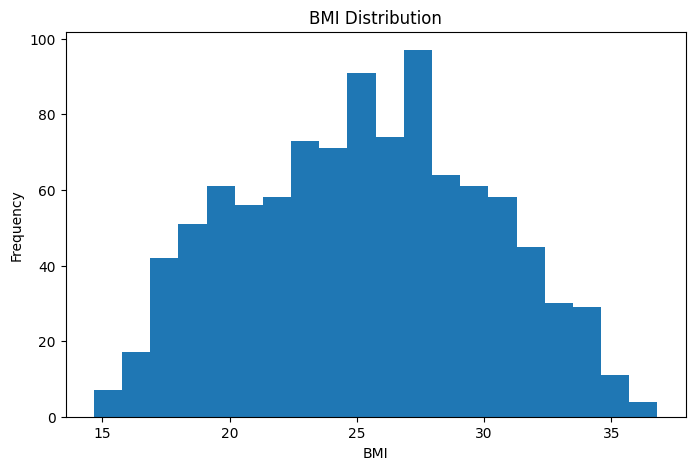

In [12]:
plt.figure(figsize=(8,5))

plt.hist(df['bmi'], bins=20)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.show()

## Project Successfully Completed

Part A:
✔ Inferential Statistics
✔ Hypothesis Testing
✔ Confidence Interval
✔ p-value
✔ Type I & Type II Errors
✔ Statistical Tests
✔ Covariance
✔ Correlation

Part B:
✔ Chi-Square Test
✔ Confidence Interval
✔ ANOVA
✔ Correlation
✔ Covariance
✔ Data Visualization

Dataset: health_dataset.csv
